In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import os
import cdsapi
import xarray as xr

In [ ]:
# Load ERA5 NetCDF
ds = xr.open_dataset('era5_weather2/data_stream-oper_stepType-instant.nc', engine='netcdf4')

# Convert from Kelvin to Celsius
ds['t2m'] = ds['t2m'] - 273.15
ds['d2m'] = ds['d2m'] - 273.15

# Compute relative humidity (approx)
rh = 100 * (np.exp((17.625 * ds['d2m']) / (243.04 + ds['d2m'])) /
            np.exp((17.625 * ds['t2m']) / (243.04 + ds['t2m'])))
ds['humidity'] = rh

# Compute wind speed
wind_speed = (ds['u10'] ** 2 + ds['v10'] ** 2) ** 0.5
ds['wind_speed'] = wind_speed

# Convert to DataFrame
df_weather = ds[['t2m', 'humidity', 'wind_speed']].to_dataframe().reset_index()
df_weather['date'] = pd.to_datetime(df_weather['valid_time']).dt.date
df_weather = df_weather.rename(columns={'latitude': 'lat', 'longitude': 'lon'})
df_weather.head(5)

,valid_time,lat,lon,t2m,humidity,wind_speed,number,expver,date
0,2024-07-01,90.0,0.00,1.049011,95.951126,4.025195,0,0001,2024-07-01
1,2024-07-01,90.0,0.25,1.049011,95.951126,4.025195,0,0001,2024-07-01
2,2024-07-01,90.0,0.50,1.049011,95.951126,4.025195,0,0001,2024-07-01
3,2024-07-01,90.0,0.75,1.049011,95.951126,4.025195,0,0001,2024-07-01
4,2024-07-01,90.0,1.00,1.049011,95.951126,4.025195,0,0001,2024-07-01


In [3]:
# iterate through later
df = pd.read_csv(r"datasets\FIRMS\MODIS\fire_archive_M-C61_599044.csv")
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,38.5422,-78.3047,304.8,2.8,1.6,2000-11-01,250,Terra,MODIS,23,6.03,280.9,40.3,N,0
1,38.5451,-78.3107,309.9,2.8,1.6,2000-11-01,250,Terra,MODIS,79,6.03,280.7,58.8,N,0
2,38.5563,-78.3084,309.4,2.8,1.6,2000-11-01,250,Terra,MODIS,70,6.03,280.4,54.5,N,0
3,38.5586,-78.3170,302.3,2.8,1.6,2000-11-01,250,Terra,MODIS,45,6.03,279.8,36.0,N,0
4,31.3393,-89.9124,304.9,1.0,1.0,2000-11-01,427,Terra,MODIS,62,6.03,287.5,8.5,N,0


In [4]:
df['acq_time'] = df['acq_time'].astype(str).str.zfill(4)
df['datetime'] = pd.to_datetime(df['acq_date'] + ' ' + df['acq_time'], format='%Y-%m-%d %H%M')
df[['acq_date', 'acq_time']].head(5)

,acq_date,acq_time
0,2000-11-01,0250
1,2000-11-01,0250
2,2000-11-01,0250
3,2000-11-01,0250
4,2000-11-01,0427


In [5]:
df['date'] = pd.to_datetime(df['acq_date']).dt.date
df['lat'] = (df['latitude'] // 0.25) * 0.25
df['lon'] = (df['longitude'] // 0.25) * 0.25

In [6]:
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,datetime,date,lat,lon
0,38.5422,-78.3047,304.8,2.8,1.6,2000-11-01,0250,Terra,MODIS,23,6.03,280.9,40.3,N,0,2000-11-01 02:50:00,2000-11-01,38.50,-78.5
1,38.5451,-78.3107,309.9,2.8,1.6,2000-11-01,0250,Terra,MODIS,79,6.03,280.7,58.8,N,0,2000-11-01 02:50:00,2000-11-01,38.50,-78.5
2,38.5563,-78.3084,309.4,2.8,1.6,2000-11-01,0250,Terra,MODIS,70,6.03,280.4,54.5,N,0,2000-11-01 02:50:00,2000-11-01,38.50,-78.5
3,38.5586,-78.3170,302.3,2.8,1.6,2000-11-01,0250,Terra,MODIS,45,6.03,279.8,36.0,N,0,2000-11-01 02:50:00,2000-11-01,38.50,-78.5
4,31.3393,-89.9124,304.9,1.0,1.0,2000-11-01,0427,Terra,MODIS,62,6.03,287.5,8.5,N,0,2000-11-01 04:27:00,2000-11-01,31.25,-90.0


In [7]:

df_unique = df.drop_duplicates(subset=['lat', 'lon', 'acq_date'], keep=False)
df_unique = df_unique.reset_index()
df_unique.head(5)

,index,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,datetime,date,lat,lon
0,4,31.3393,-89.9124,304.9,1.0,1.0,2000-11-01,0427,Terra,MODIS,62,6.03,287.5,8.5,N,0,2000-11-01 04:27:00,2000-11-01,31.25,-90.00
1,5,32.6448,-94.6467,303.3,1.2,1.1,2000-11-01,0427,Terra,MODIS,54,6.03,290.1,7.4,N,0,2000-11-01 04:27:00,2000-11-01,32.50,-94.75
2,13,41.6370,-87.1427,301.6,1.8,1.3,2000-11-01,0430,Terra,MODIS,43,6.03,277.5,18.2,N,2,2000-11-01 04:30:00,2000-11-01,41.50,-87.25
3,14,38.4464,-120.3885,302.9,1.1,1.1,2000-11-01,0608,Terra,MODIS,52,6.03,273.5,11.3,N,0,2000-11-01 06:08:00,2000-11-01,38.25,-120.50
4,15,43.4890,-123.6513,302.9,1.3,1.1,2000-11-01,0609,Terra,MODIS,52,6.03,271.5,14.1,N,0,2000-11-01 06:09:00,2000-11-01,43.25,-123.75


In [13]:
c = cdsapi.Client()

for idx, row in df_unique.iterrows():
    lat = row['lat']
    lon = row['lon']
    date = pd.to_datetime(row['acq_date'])
    
    year = str(date.year)
    month = f"{date.month:02d}"
    day = f"{date.day:02d}"
    hour = "00:00"  # Or adjust based on acq_time if you want finer control

    area = [
        lat + 0.25, lon - 0.25,  # North, West
        lat - 0.25, lon + 0.25   # South, East
    ]

    output_filename = f"./datasets/era5/era5_fire_{year}{month}{day}_{lat:.2f}_{lon:.2f}.zip"

    print(f"Requesting data for {date.date()} at lat: {lat}, lon: {lon}")

    c.retrieve(
        'reanalysis-era5-single-levels',
        {
            "product_type": "reanalysis",
            "variable": [
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "2m_dewpoint_temperature",
                "2m_temperature",
                "mean_sea_level_pressure",
                "sea_surface_temperature",
                "significant_height_of_combined_wind_waves_and_swell",
                "surface_pressure",
                "total_precipitation"
            ],
            "year": year,
            "month": month,
            "day": day,
            "time": [str(x) + ":00" for x in range(0, 24)],
            "area": area,
            "data_format": "netcdf"
        },
        output_filename
    )

    # Optional: break after a few for testing
    if idx >= 2:
        break

2025-04-13 21:53:37,722 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-04-13 21:53:37,722 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.


Requesting data for 2000-11-01 at lat: 31.25, lon: -90.0


2025-04-13 21:53:39,916 INFO Request ID is 16246566-5d48-4caa-97a5-0475bc94f6bf
2025-04-13 21:53:40,285 INFO status has been updated to accepted
2025-04-13 21:54:14,984 INFO status has been updated to successful


248ff94da2724a05b98bc8b6c81a83ea.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

Requesting data for 2000-11-01 at lat: 32.5, lon: -94.75


2025-04-13 21:54:20,020 INFO Request ID is 873b4054-cc5a-440d-8dd8-d192c103cb7d
2025-04-13 21:54:20,357 INFO status has been updated to accepted
2025-04-13 21:54:29,886 INFO status has been updated to running
2025-04-13 21:54:43,200 INFO status has been updated to successful


215a0b617972a2df950951d4ce14b337.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

Requesting data for 2000-11-01 at lat: 41.5, lon: -87.25


2025-04-13 21:54:48,842 INFO Request ID is 2634cef8-f84f-4857-895f-70f6c0a2ec44
2025-04-13 21:54:49,224 INFO status has been updated to accepted
2025-04-13 21:55:04,285 INFO status has been updated to successful


779e0d4e711a93c4845cee3c1e94c531.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

In [12]:
df1 = xr.open_dataset('./datasets/era5/era5_fire_20001101_31.25_-90.00.nc', engine='netcdf4')
df1.head(5)

OSError: [Errno -51] NetCDF: Unknown file format: 'c:\\Users\\olive\\cs5131proj\\datasets\\era5\\era5_fire_20001101_31.25_-90.00.nc'

In [ ]:
# Mark fire cells
df['fire_label'] = 1
fire_cells = df[['lat', 'lon', 'date', 'fire_label']].drop_duplicates()
fire_cells.head(5)

,lat,lon,date,fire_label
0,38.50,-78.50,2000-11-01,1
4,31.25,-90.00,2000-11-01,1
5,32.50,-94.75,2000-11-01,1
6,31.75,-95.25,2000-11-01,1
8,36.50,-84.00,2000-11-01,1


In [ ]:

# Merge with weather
merged = df_weather.merge(fire_cells, on=['lat', 'lon', 'date'], how='inner')
merged['fire_label'] = merged['fire_label'].fillna(0)  # No fire = 0


In [ ]:
merged.head(5)

,valid_time,lat,lon,t2m,humidity,wind_speed,number,expver,date,fire_label


In [ ]:
fires_daily = df.groupby(df['datetime'].dt.date).agg({
    'brightness': 'mean',
    'bright_t31': 'mean',
    'frp': 'mean',
    'latitude': 'count'
}).rename(columns={'latitude': 'fire_count'})

fires_daily.head(5)

,brightness,bright_t31,frp,fire_count
datetime,,,,
2000-11-01,316.330000,291.493077,21.699231,260
2000-11-02,313.003245,286.321239,29.215339,339
2000-11-03,315.840698,288.073643,28.141860,258
2000-11-04,312.785246,281.165574,23.560656,61
2000-11-05,316.954545,287.136364,30.765909,44


In [ ]:
fires_daily['label'] = (fires_daily['fire_count'] > 0).astype(int)
fires_daily['label'].head(5)

datetime
2000-11-01    1
2000-11-02    1
2000-11-03    1
2000-11-04    1
2000-11-05    1
Name: label, dtype: int64

In [ ]:
features = fires_daily[['brightness', 'bright_t31', 'frp']].fillna(0)
labels = fires_daily['label'].values

In [ ]:
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

def seq(data, labels, window=7):
    x,y=[],[]
    for i in range(len(data)-window):
        x.append(data[i:i+window])
        y.append(labels[i+window])
    return np.array(x), np.array(y)

x, y = seq(features_scaled, labels)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

model = Sequential([
    LSTM(64, input_shape=(x.shape[1], x.shape[2])),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=16, validation_data=(x_test, y_test))

Epoch 1/5


c:\Users\olive\cs5131proj\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


440/440 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 0.1139 - val_accuracy: 1.0000 - val_loss: 5.3187e-05
Epoch 2/5
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 4.1862e-05 - val_accuracy: 1.0000 - val_loss: 2.3437e-05
Epoch 3/5
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 2.0520e-05 - val_accuracy: 1.0000 - val_loss: 1.4588e-05
Epoch 4/5
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.3264e-05 - val_accuracy: 1.0000 - val_loss: 1.0300e-05
Epoch 5/5
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 9.5576e-06 - val_accuracy: 1.0000 - val_loss: 7.7050e-06


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1759

    accuracy                           1.00      1759
   macro avg       1.00      1.00      1.00      1759
weighted avg       1.00      1.00      1.00      1759



c:\Users\olive\cs5131proj\venv\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


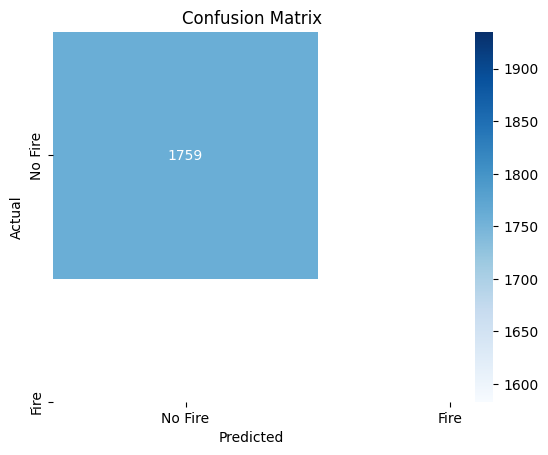

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_prob = model.predict(x_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
fires_daily['label'].value_counts()

label
1    8798
Name: count, dtype: int64